# 🛒 Olist eCommerce Store Performance Audit
## Phase 3 — EDA Visualizations & RFM Customer Segmentation

**Author:** Smit Bhavsar  
**Tools:** Python · Pandas · Matplotlib · Seaborn  
**Data:** sql_results/ folder (Phase 2 exports) + cleaned_data/olist_delivered.csv

---
### What this phase covers
- **Part A** — 8 EDA charts built from Phase 2 SQL results
- **Part B** — RFM Customer Segmentation with business recommendations
- **Part C** — Save all outputs for Power BI dashboard
---

## Step 1 — Setup & Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

# ── Paths (notebook is inside notebooks/ subfolder) ──
SQL     = '../sql_results/'
CLEANED = '../cleaned_data/'
IMAGES  = '../images/'

os.makedirs(IMAGES, exist_ok=True)

print('✅ Setup complete!')
print(f'   SQL results : {SQL}')
print(f'   Cleaned data: {CLEANED}')
print(f'   Images      : {IMAGES}')

✅ Setup complete!
   SQL results : ../sql_results/
   Cleaned data: ../cleaned_data/
   Images      : ../images/


## Step 2 — Load All Data Files

In [2]:
# Phase 2 SQL export files
df_monthly  = pd.read_csv(SQL + 'query1_monthly_revenue.csv')
df_category = pd.read_csv(SQL + 'query2_category_revenue.csv')
df_repeat   = pd.read_csv(SQL + 'query3_customer_repeat.csv')
df_delivery = pd.read_csv(SQL + 'query4_delivery_by_state.csv')
df_review   = pd.read_csv(SQL + 'query5_review_vs_delay.csv')
df_payment  = pd.read_csv(SQL + 'query6_payment_analysis.csv')
df_cancel   = pd.read_csv(SQL + 'query7_cancellation_rate.csv')
df_photos   = pd.read_csv(SQL + 'query8c_product_photo_vs_individual_score.csv')
df_day      = pd.read_csv(SQL + 'query9a_orders_by_day.csv')
df_hour     = pd.read_csv(SQL + 'query9b_orders_by_hour.csv')
df_geo      = pd.read_csv(SQL + 'query10_geographic_revenue.csv')
df_freight  = pd.read_csv(SQL + 'query11_freight_analysis.csv')
df_seasonal = pd.read_csv(SQL + 'query12_seasonal_spikes.csv')
df_rfm      = pd.read_csv(SQL + 'bonus_RFM_segmantation.csv')

# Main delivered dataset
df_delivered = pd.read_csv(
    CLEANED + 'olist_delivered.csv',
    parse_dates=['order_purchase_timestamp']
)

print('✅ All files loaded!')
print(f'   Monthly revenue rows  : {len(df_monthly)}')
print(f'   Category revenue rows : {len(df_category)}')
print(f'   Customer repeat rows  : {len(df_repeat)}')
print(f'   RFM rows              : {len(df_rfm):,}')
print(f'   Delivered orders rows : {len(df_delivered):,}')

✅ All files loaded!
   Monthly revenue rows  : 20
   Category revenue rows : 74
   Customer repeat rows  : 4
   RFM rows              : 93,358
   Delivered orders rows : 96,478


---
# PART A — EDA Visualizations

## Chart 1 — Monthly Revenue Trend

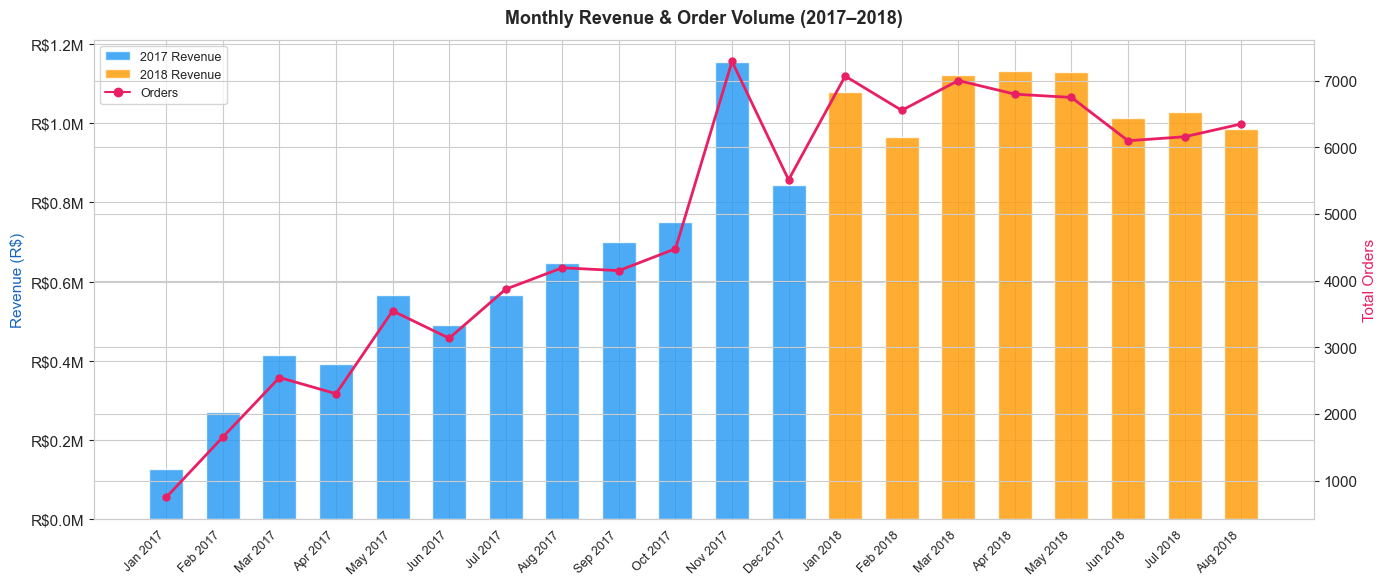

✅ Chart 1 saved!


In [14]:
df_monthly = df_monthly.sort_values(
    ['order_year','order_month']
).reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(14, 6))

bar_colors = [
    '#2196F3' if y == 2017 else '#FF9800'
    for y in df_monthly['order_year']
]
ax1.bar(
    range(len(df_monthly)),
    df_monthly['monthly_revenue'],
    color=bar_colors, alpha=0.8, width=0.6
)
ax1.set_ylabel('Revenue (R$)', color='#1565C0')
ax1.set_xticks(range(len(df_monthly)))
ax1.set_xticklabels(
    df_monthly['order_month_name'],
    rotation=45, ha='right', fontsize=9
)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'R${x/1e6:.1f}M')
)

ax2 = ax1.twinx()
ax2.plot(
    range(len(df_monthly)),
    df_monthly['total_orders'],
    color='#E91E63', marker='o',
    linewidth=2, markersize=5
)
ax2.set_ylabel('Total Orders', color='#E91E63')

legend_els = [
    Patch(facecolor='#2196F3', alpha=0.8, label='2017 Revenue'),
    Patch(facecolor='#FF9800', alpha=0.8, label='2018 Revenue'),
    plt.Line2D([0],[0], color='#E91E63', marker='o', label='Orders')
]
ax1.legend(handles=legend_els, loc='upper left', fontsize=9)
plt.title('Monthly Revenue & Order Volume (2017–2018)', pad=12)
fig.tight_layout()
plt.savefig(IMAGES+'chart1_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 1 saved!')

## Chart 2 — Top 10 Product Categories by Revenue

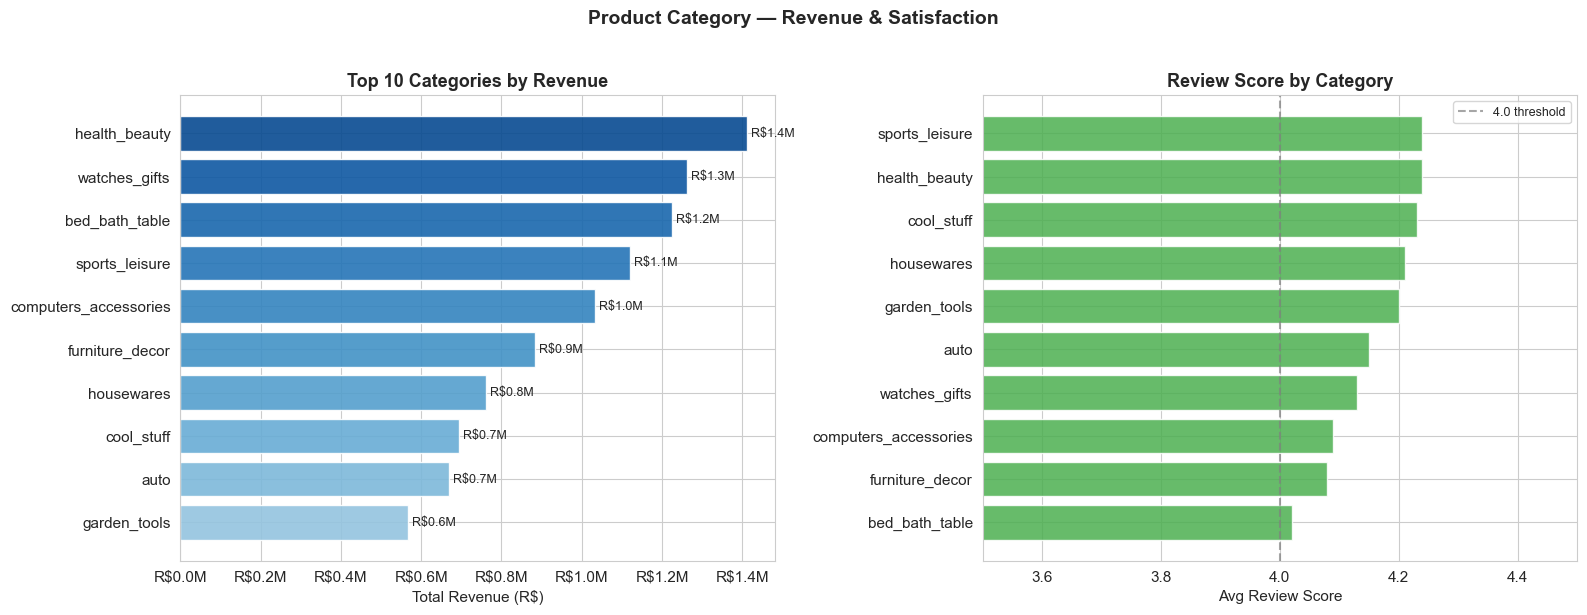

✅ Chart 2 saved!


In [21]:
top10 = df_category.head(10).sort_values('revenue', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — revenue bar
bar_c = plt.cm.Blues(np.linspace(0.4, 0.9, len(top10)))
bars = axes[0].barh(
    top10['product_category'], top10['revenue'],
    color=bar_c, alpha=0.9
)
for bar, val in zip(bars, top10['revenue']):
    axes[0].text(
        bar.get_width() + 10000,
        bar.get_y() + bar.get_height()/2,
        f'R${val/1e6:.1f}M', va='center', fontsize=9
    )
axes[0].set_xlabel('Total Revenue (R$)')
axes[0].set_title('Top 10 Categories by Revenue')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'R${x/1e6:.1f}M')
)

# Right — review score
top10_r = df_category.head(10).sort_values('avg_review_score', ascending=True)
rev_colors = [
    '#4CAF50' if s >= 4.0 else '#FF9800' if s >= 3.5 else '#F44336'
    for s in top10_r['avg_review_score']
]
axes[1].barh(
    top10_r['product_category'],
    top10_r['avg_review_score'],
    color=rev_colors, alpha=0.85
)
axes[1].axvline(x=4.0, color='gray', linestyle='--',
                alpha=0.7, label='4.0 threshold')
axes[1].set_xlabel('Avg Review Score')
axes[1].set_title('Review Score by Category')
axes[1].set_xlim(3.5, 4.5)
axes[1].legend(fontsize=9)

plt.suptitle('Product Category — Revenue & Satisfaction',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMAGES+'chart2_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 2 saved!')

## Chart 3 — Customer Repeat Purchase (KEY INSIGHT #1)

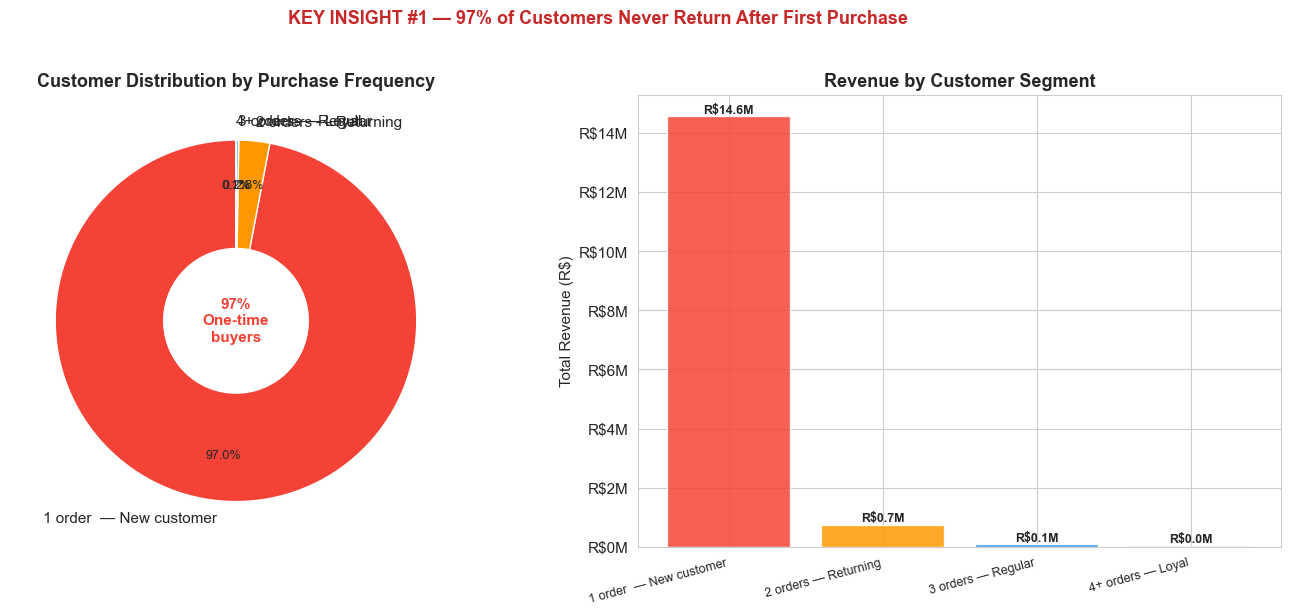

✅ Chart 3 saved — KEY INSIGHT #1!


In [27]:
seg_colors = ['#F44336','#FF9800','#2196F3','#4CAF50']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — donut chart
wedges, texts, autos = axes[0].pie(
    df_repeat['customer_count'],
    labels=df_repeat['customer_segment'],
    autopct='%1.1f%%',
    colors=seg_colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'width': 0.6}
)
for t in autos:
    t.set_fontsize(9)
axes[0].text(0, 0, '97%\nOne-time\nbuyers',
             ha='center', va='center',
             fontsize=11, fontweight='bold', color='#F44336')
axes[0].set_title('Customer Distribution by Purchase Frequency')

# Right — revenue comparison
bars = axes[1].bar(
    df_repeat['customer_segment'],
    df_repeat['segment_revenue'],
    color=seg_colors, alpha=0.85
)
for bar, val in zip(bars, df_repeat['segment_revenue']):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 100000,
        f'R${val/1e6:.1f}M',
        ha='center', fontsize=9, fontweight='bold'
    )
axes[1].set_ylabel('Total Revenue (R$)')
axes[1].set_title('Revenue by Customer Segment')
axes[1].set_xticklabels(
    df_repeat['customer_segment'],
    rotation=15, ha='right', fontsize=9
)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'R${x/1e6:.0f}M')
)

plt.suptitle(
    'KEY INSIGHT #1 — 97% of Customers Never Return After First Purchase',
    fontsize=13, fontweight='bold', color='#C62828', y=1.02
)
plt.tight_layout()
plt.savefig(IMAGES+'chart3_repeat_purchase.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 3 saved — KEY INSIGHT #1!')

## Chart 4 — Review Score vs Delivery (KEY INSIGHT #2)

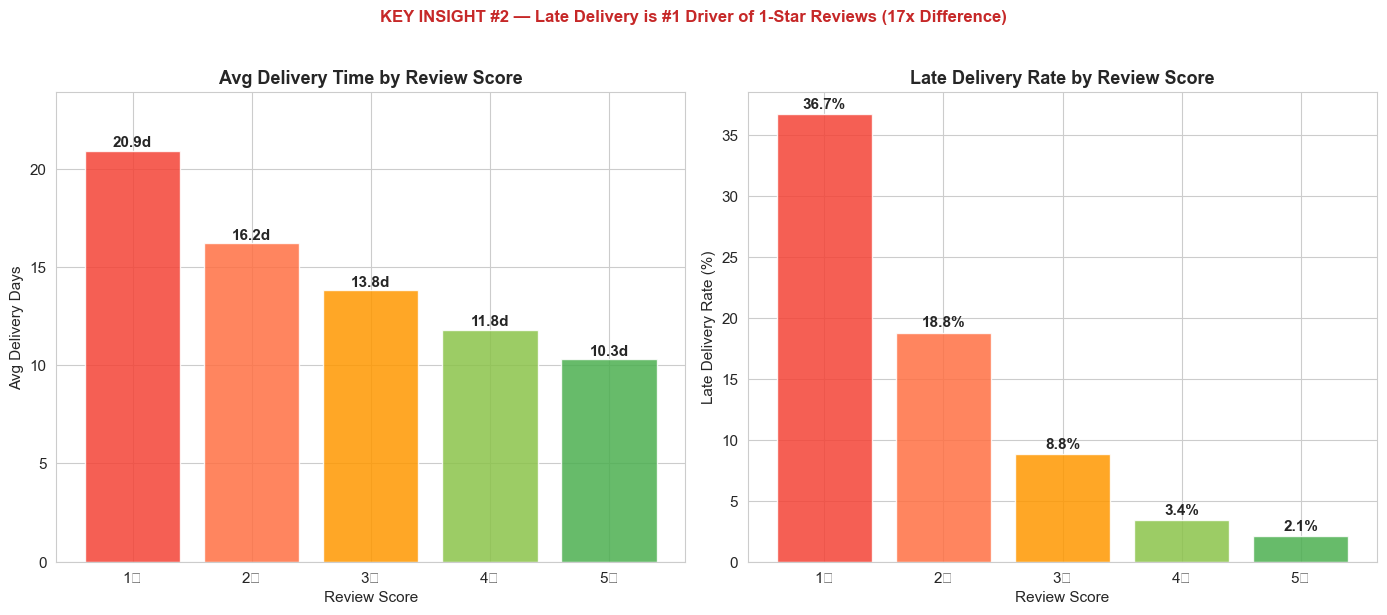

✅ Chart 4 saved — KEY INSIGHT #2!


In [35]:
df_review = df_review.sort_values('review_score').reset_index(drop=True)
score_colors = ['#F44336','#FF7043','#FF9800','#8BC34A','#4CAF50']
labels = [f'{int(s)}★' for s in df_review['review_score']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — avg delivery days
bars1 = axes[0].bar(labels, df_review['avg_actual_delivery_days'],
                    color=score_colors, alpha=0.85)
for bar, val in zip(bars1, df_review['avg_actual_delivery_days']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'{val:.1f}d', ha='center', fontsize=11, fontweight='bold'
    )
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Avg Delivery Days')
axes[0].set_title('Avg Delivery Time by Review Score')
axes[0].set_ylim(0, df_review['avg_actual_delivery_days'].max() + 3)

# Right — late delivery %
bars2 = axes[1].bar(labels, df_review['pct_delivered_late'],
                    color=score_colors, alpha=0.85)
for bar, val in zip(bars2, df_review['pct_delivered_late']):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold'
    )
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Late Delivery Rate (%)')
axes[1].set_title('Late Delivery Rate by Review Score')

plt.suptitle(
    'KEY INSIGHT #2 — Late Delivery is #1 Driver of 1-Star Reviews (17x Difference)',
    fontsize=12, fontweight='bold', color='#C62828', y=1.02
)
plt.tight_layout()
plt.savefig(IMAGES+'chart4_review_vs_delay.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 4 saved — KEY INSIGHT #2!')

## Chart 5 — Payment Method Analysis

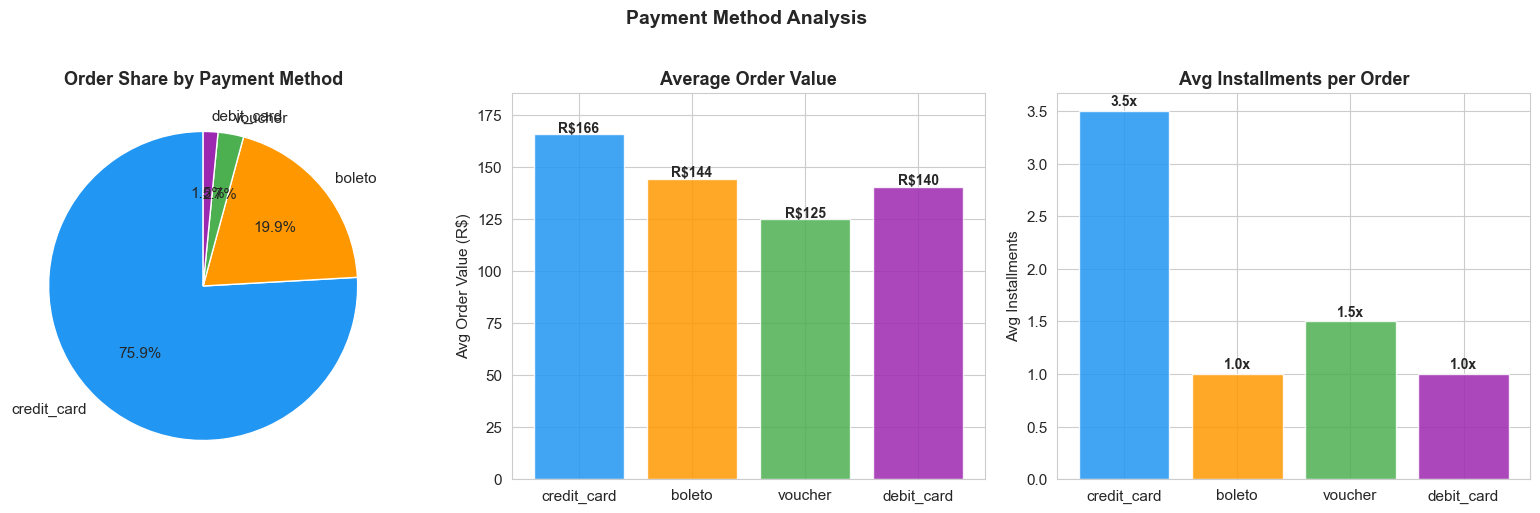

✅ Chart 5 saved!


In [41]:
df_pay = df_payment[
    ~df_payment['payment_type'].isin(['unknown','not_defined'])
].copy()

pay_colors = ['#2196F3','#FF9800','#4CAF50','#9C27B0']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pie
axes[0].pie(
    df_pay['total_orders'],
    labels=df_pay['payment_type'],
    autopct='%1.1f%%',
    colors=pay_colors, startangle=90
)
axes[0].set_title('Order Share by Payment Method')

# AOV
bars = axes[1].bar(
    df_pay['payment_type'], df_pay['avg_order_value'],
    color=pay_colors, alpha=0.85
)
for bar, val in zip(bars, df_pay['avg_order_value']):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'R${val:.0f}', ha='center', fontsize=10, fontweight='bold'
    )
axes[1].set_ylabel('Avg Order Value (R$)')
axes[1].set_title('Average Order Value')
axes[1].set_ylim(0, df_pay['avg_order_value'].max() + 20)

# Installments
bars2 = axes[2].bar(
    df_pay['payment_type'], df_pay['avg_installments'],
    color=pay_colors, alpha=0.85
)
for bar, val in zip(bars2, df_pay['avg_installments']):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f'{val:.1f}x', ha='center', fontsize=10, fontweight='bold'
    )
axes[2].set_ylabel('Avg Installments')
axes[2].set_title('Avg Installments per Order')

plt.suptitle('Payment Method Analysis', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMAGES+'chart5_payment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 5 saved!')

## Chart 6 — Shopping Patterns (Day & Hour)

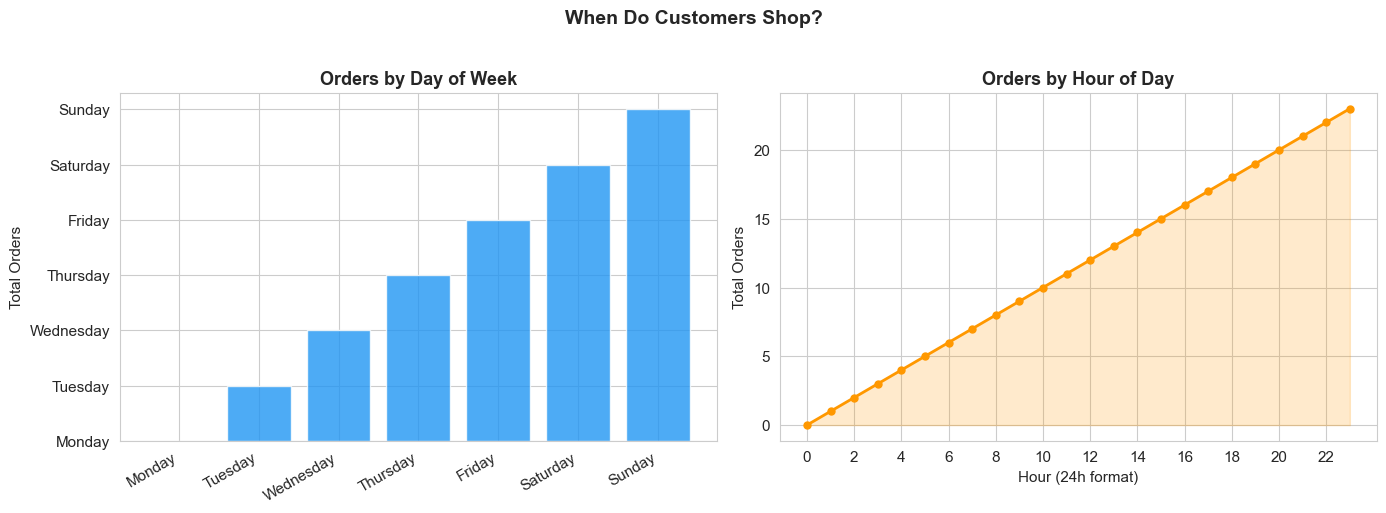

✅ Chart 6 saved!


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day of week — detect column names from pgAdmin export
day_col   = [c for c in df_day.columns  if 'day'   in c.lower()][0]
dord_col  = [c for c in df_day.columns  if 'order' in c.lower()][0]
hour_col  = [c for c in df_hour.columns if 'hour'  in c.lower()][0]
hord_col  = [c for c in df_hour.columns if 'order' in c.lower()][0]

day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']
df_day_s = (
    df_day.set_index(day_col)
    .reindex([d for d in day_order if d in df_day[day_col].values])
    .reset_index()
)

axes[0].bar(df_day_s[day_col], df_day_s[dord_col],
            color='#2196F3', alpha=0.8)
axes[0].set_title('Orders by Day of Week')
axes[0].set_ylabel('Total Orders')
axes[0].set_xticklabels(df_day_s[day_col], rotation=30, ha='right')

df_hour_s = df_hour.sort_values(hour_col)
axes[1].plot(df_hour_s[hour_col], df_hour_s[hord_col],
             color='#FF9800', marker='o', linewidth=2, markersize=5)
axes[1].fill_between(df_hour_s[hour_col], df_hour_s[hord_col],
                     alpha=0.2, color='#FF9800')
axes[1].set_title('Orders by Hour of Day')
axes[1].set_xlabel('Hour (24h format)')
axes[1].set_ylabel('Total Orders')
axes[1].set_xticks(range(0, 24, 2))

plt.suptitle('When Do Customers Shop?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMAGES+'chart6_shopping_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 6 saved!')

## Chart 7 — Delivery Performance by State

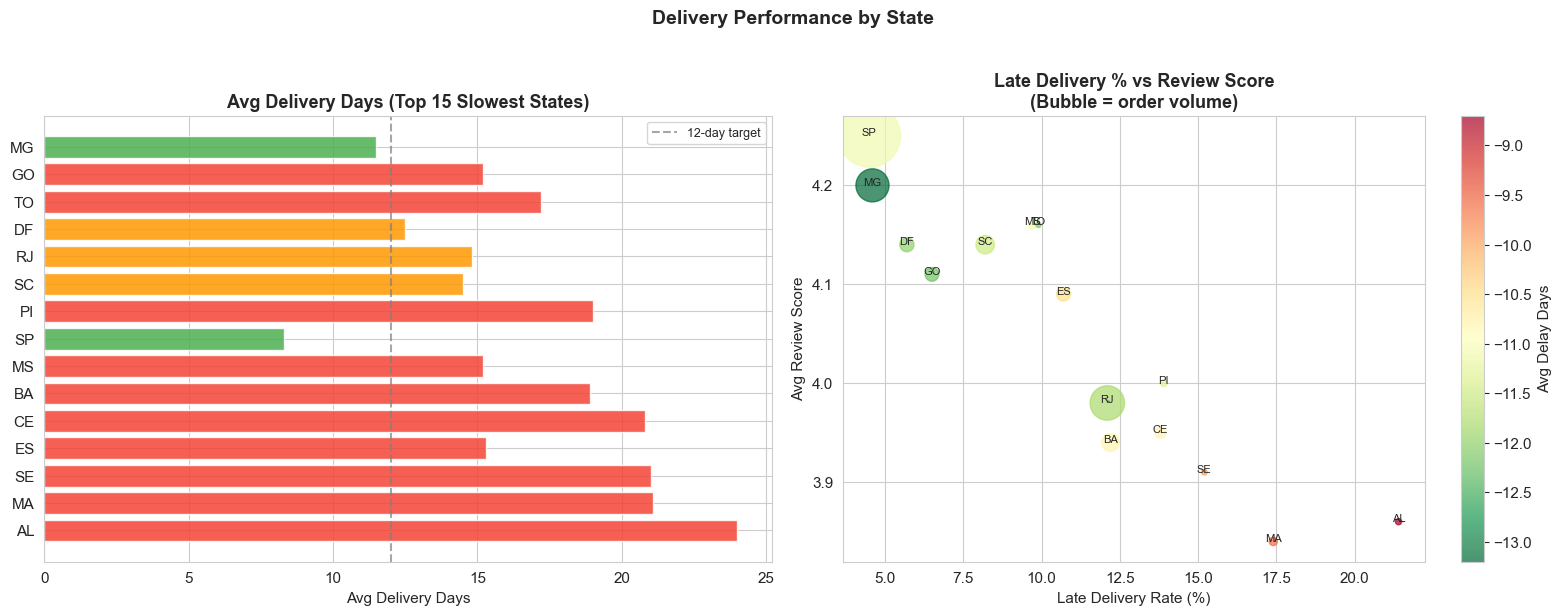

✅ Chart 7 saved!


In [48]:
df_del_s = df_delivery.sort_values(
    'avg_delay_days', ascending=False
).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — delivery days bar
del_colors = [
    '#F44336' if v > 15 else '#FF9800' if v > 12 else '#4CAF50'
    for v in df_del_s['avg_delivery_days']
]
axes[0].barh(df_del_s['customer_state'],
             df_del_s['avg_delivery_days'],
             color=del_colors, alpha=0.85)
axes[0].axvline(x=12, color='gray', linestyle='--',
                alpha=0.7, label='12-day target')
axes[0].set_xlabel('Avg Delivery Days')
axes[0].set_title('Avg Delivery Days (Top 15 Slowest States)')
axes[0].legend(fontsize=9)

# Right — scatter late % vs review score
sc = axes[1].scatter(
    df_del_s['late_delivery_pct'],
    df_del_s['avg_review_score'],
    s=df_del_s['total_orders'] / 20,
    alpha=0.7,
    c=df_del_s['avg_delay_days'],
    cmap='RdYlGn_r'
)
for _, row in df_del_s.iterrows():
    axes[1].annotate(
        row['customer_state'],
        (row['late_delivery_pct'], row['avg_review_score']),
        fontsize=8, ha='center'
    )
plt.colorbar(sc, ax=axes[1], label='Avg Delay Days')
axes[1].set_xlabel('Late Delivery Rate (%)')
axes[1].set_ylabel('Avg Review Score')
axes[1].set_title('Late Delivery % vs Review Score\n(Bubble = order volume)')

plt.suptitle('Delivery Performance by State',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMAGES+'chart7_delivery_by_state.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 7 saved!')

## Chart 8 — Product Photos vs Review Score

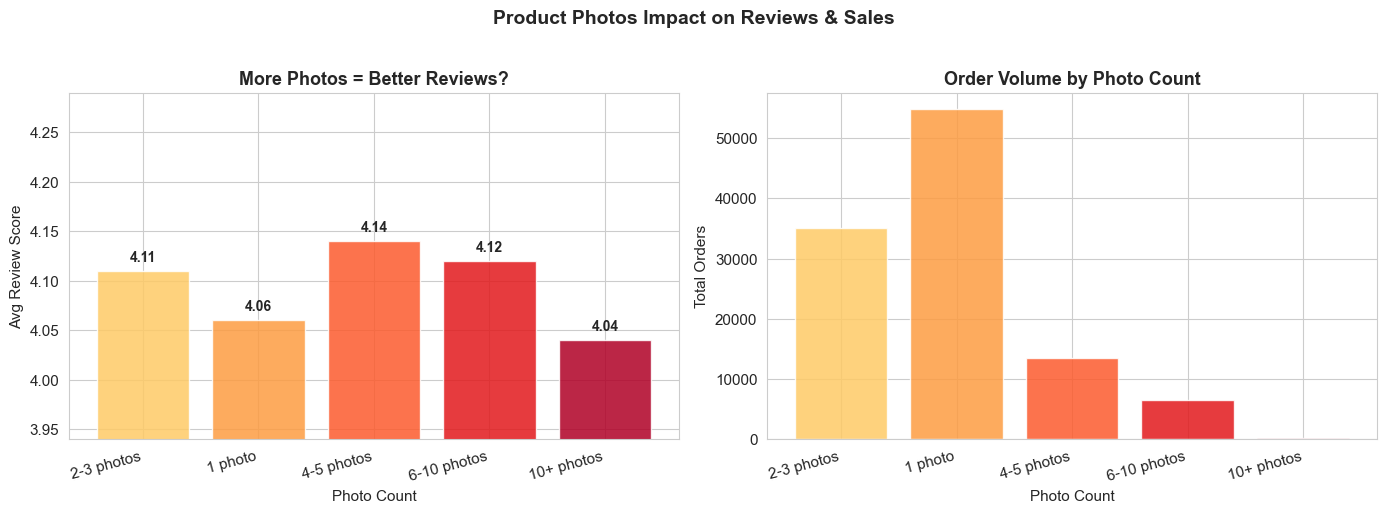

✅ Chart 8 saved!


In [52]:
photo_col  = [c for c in df_photos.columns if 'photo'  in c.lower()][0]
review_col = [c for c in df_photos.columns if 'review' in c.lower()][0]
order_col  = [c for c in df_photos.columns if 'order'  in c.lower()][0]

ph_colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(df_photos)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(df_photos[photo_col], df_photos[review_col],
                   color=ph_colors, alpha=0.85)
for bar, val in zip(bars, df_photos[review_col]):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.2f}', ha='center', fontsize=10, fontweight='bold'
    )
axes[0].set_xlabel('Photo Count')
axes[0].set_ylabel('Avg Review Score')
axes[0].set_title('More Photos = Better Reviews?')
axes[0].set_ylim(
    df_photos[review_col].min() - 0.1,
    df_photos[review_col].max() + 0.15
)
axes[0].set_xticklabels(df_photos[photo_col], rotation=15, ha='right')

axes[1].bar(df_photos[photo_col], df_photos[order_col],
            color=ph_colors, alpha=0.85)
axes[1].set_xlabel('Photo Count')
axes[1].set_ylabel('Total Orders')
axes[1].set_title('Order Volume by Photo Count')
axes[1].set_xticklabels(df_photos[photo_col], rotation=15, ha='right')

plt.suptitle('Product Photos Impact on Reviews & Sales',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMAGES+'chart8_photos_vs_reviews.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 8 saved!')

---
# PART B — RFM Customer Segmentation

## Step B1 — Inspect RFM Data from pgAdmin

In [54]:
print('RFM file columns:', df_rfm.columns.tolist())
print('Shape:', df_rfm.shape)
print()
print('Sample rows:')
print(df_rfm.head())
print()
print('Segments found:')
print(df_rfm['rfm_segment'].value_counts())

RFM file columns: ['customer_unique_id', 'recency_days', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_total', 'rfm_segment']
Shape: (93358, 9)

Sample rows:
                 customer_unique_id  recency_days  frequency  monetary  \
0  aad99270bc43606a7af9647b7a7de9e4            67          1    320.31   
1  0eb917bbd8203a7bf6c6447610778d94           123          1    218.70   
2  4aa1ebcfbf59d20f68d324b24450ccbc            59          1    252.38   
3  ab451b486278ea9f8e30f3eff137ebd4            59          1    329.55   
4  34bfe7d8aeeccdcb18d7eed0b6607d7a           126          1    420.29   

   r_score  f_score  m_score  rfm_total rfm_segment  
0        5        5        5         15   Champions  
1        5        5        5         15   Champions  
2        5        5        5         15   Champions  
3        5        5        5         15   Champions  
4        5        5        5         15   Champions  

Segments found:
rfm_segment
At-Risk Customers      2186

## Step B2 — Build Segment Summary

In [55]:
seg_summary = df_rfm.groupby('rfm_segment').agg(
    customer_count = ('customer_unique_id', 'count'),
    avg_recency    = ('recency_days', 'mean'),
    avg_frequency  = ('frequency', 'mean'),
    avg_monetary   = ('monetary', 'mean'),
    total_revenue  = ('monetary', 'sum')
).round(2).reset_index()

seg_summary['pct_customers'] = (
    seg_summary['customer_count']
    / seg_summary['customer_count'].sum() * 100
).round(1)

seg_summary['pct_revenue'] = (
    seg_summary['total_revenue']
    / seg_summary['total_revenue'].sum() * 100
).round(1)

seg_summary = seg_summary.sort_values('total_revenue', ascending=False)

print('RFM Segment Summary:')
print(seg_summary.to_string(index=False))

RFM Segment Summary:
        rfm_segment  customer_count  avg_recency  avg_frequency  avg_monetary  total_revenue  pct_customers  pct_revenue
  At-Risk Customers           21867       442.94           1.05        242.98     5313142.85          23.40        34.50
          Champions           14867       140.60           1.08        309.05     4594693.09          15.90        29.80
    Loyal Customers           19055       215.39           1.04        180.20     3433629.61          20.40        22.30
   Recent Customers           14378       139.02           1.00         54.84      788501.49          15.40         5.10
   Cannot Lose Them            8047       442.61           1.01         70.50      567280.68           8.60         3.70
    Needs Attention           11067       299.63           1.00         49.90      552267.81          11.90         3.60
     Lost Customers            3897       525.36           1.00         40.06      156103.28           4.20         1.00
          P

## Chart 9 — RFM Segment Bar Charts

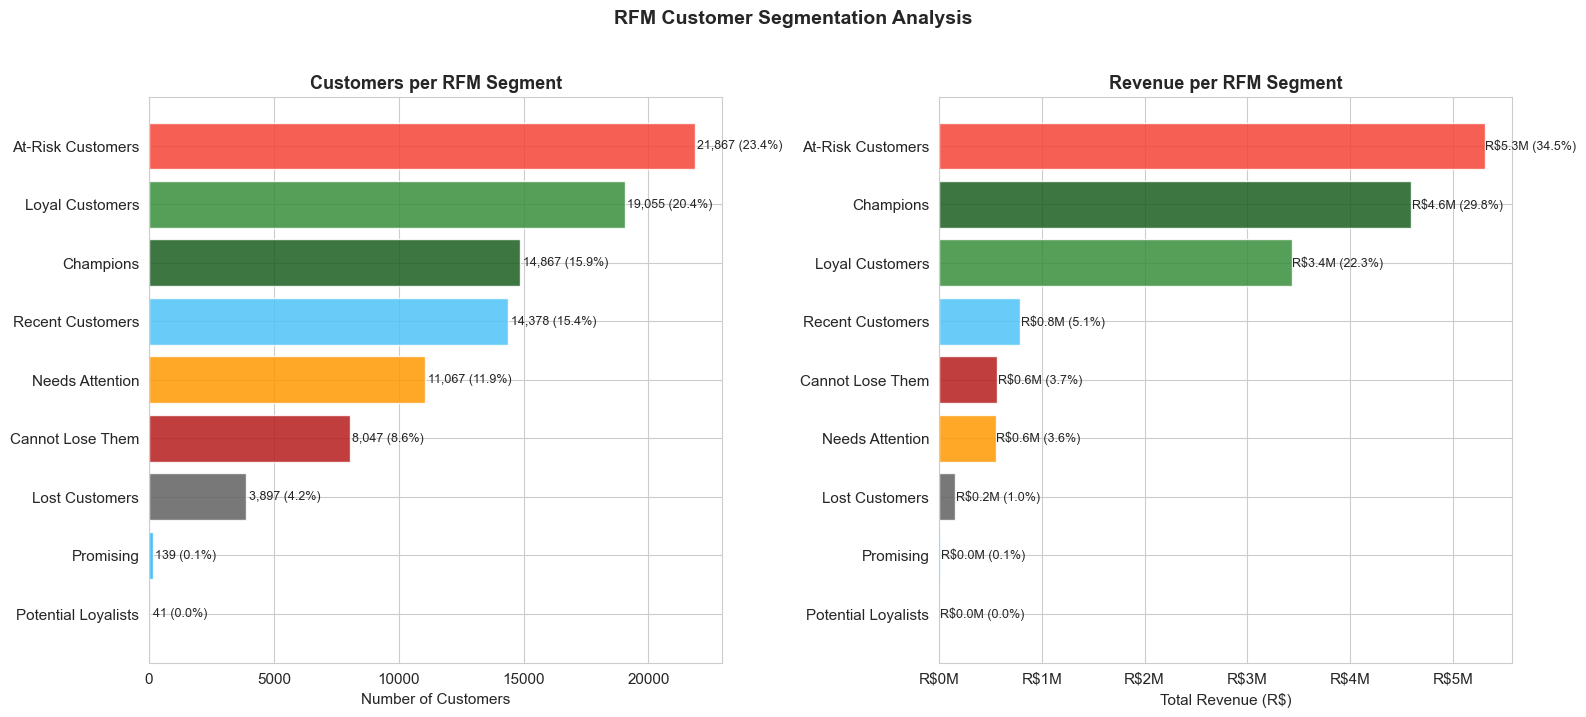

✅ Chart 9 saved!


In [57]:
SEGMENT_COLORS = {
    'Champions':           '#1B5E20',
    'Loyal Customers':     '#388E3C',
    'Potential Loyalists': '#66BB6A',
    'Recent Customers':    '#4FC3F7',
    'Promising':           '#29B6F6',
    'Needs Attention':     '#FF9800',
    'At-Risk Customers':   '#F44336',
    'Cannot Lose Them':    '#B71C1C',
    'Lost Customers':      '#616161'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left — customer count
sc = seg_summary.sort_values('customer_count')
cc = [SEGMENT_COLORS.get(s,'#9E9E9E') for s in sc['rfm_segment']]
b1 = axes[0].barh(sc['rfm_segment'], sc['customer_count'],
                  color=cc, alpha=0.85)
for bar, val, pct in zip(b1, sc['customer_count'], sc['pct_customers']):
    axes[0].text(
        bar.get_width() + 100,
        bar.get_y() + bar.get_height()/2,
        f'{val:,} ({pct}%)', va='center', fontsize=9
    )
axes[0].set_title('Customers per RFM Segment')
axes[0].set_xlabel('Number of Customers')

# Right — revenue
sr = seg_summary.sort_values('total_revenue')
rc = [SEGMENT_COLORS.get(s,'#9E9E9E') for s in sr['rfm_segment']]
b2 = axes[1].barh(sr['rfm_segment'], sr['total_revenue'],
                  color=rc, alpha=0.85)
for bar, val, pct in zip(b2, sr['total_revenue'], sr['pct_revenue']):
    axes[1].text(
        bar.get_width() + 5000,
        bar.get_y() + bar.get_height()/2,
        f'R${val/1e6:.1f}M ({pct}%)', va='center', fontsize=9
    )
axes[1].set_title('Revenue per RFM Segment')
axes[1].set_xlabel('Total Revenue (R$)')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'R${x/1e6:.0f}M')
)

plt.suptitle('RFM Customer Segmentation Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMAGES+'chart9_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 9 saved!')

## Chart 10 — RFM Scatter Plot

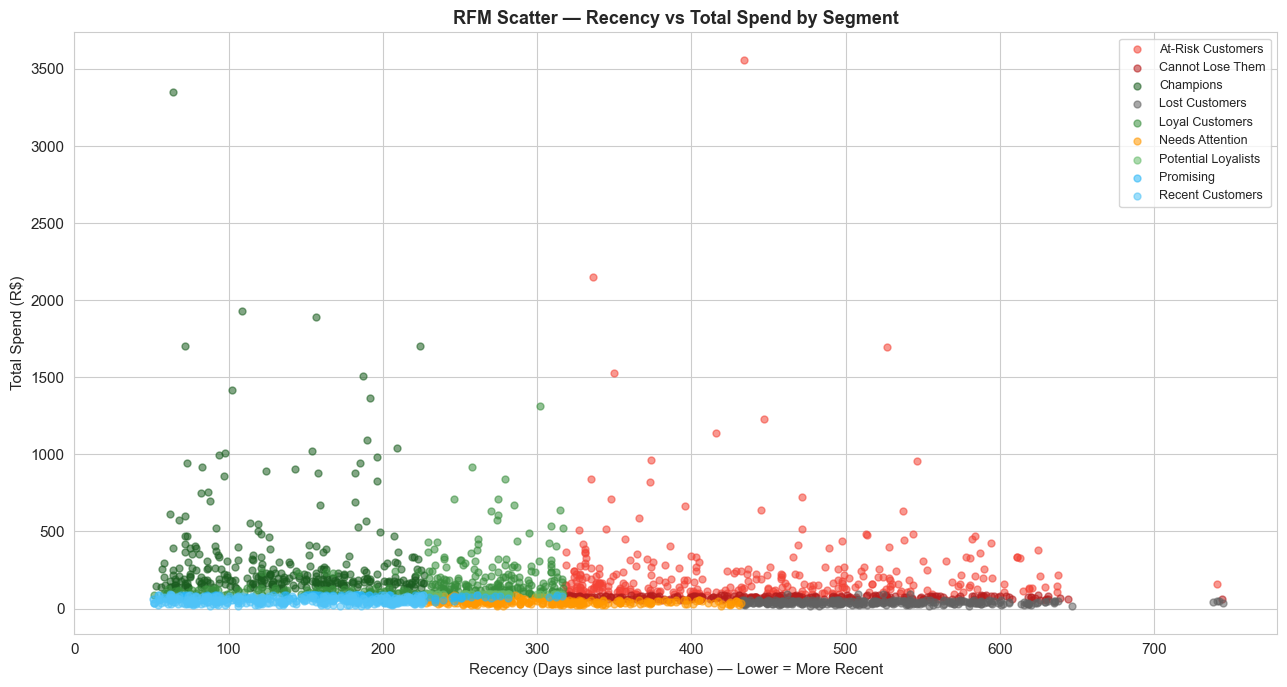

✅ Chart 10 saved!


In [59]:
fig, ax = plt.subplots(figsize=(13, 7))

for segment, group in df_rfm.groupby('rfm_segment'):
    sample = group.sample(min(300, len(group)), random_state=42)
    ax.scatter(
        sample['recency_days'],
        sample['monetary'],
        label=segment,
        alpha=0.55, s=25,
        color=SEGMENT_COLORS.get(segment, '#9E9E9E')
    )

ax.set_xlabel(
    'Recency (Days since last purchase) — Lower = More Recent',
    fontsize=11
)
ax.set_ylabel('Total Spend (R$)', fontsize=11)
ax.set_title(
    'RFM Scatter — Recency vs Total Spend by Segment',
    fontsize=13, fontweight='bold'
)
ax.legend(loc='upper right', fontsize=9, framealpha=0.8)
ax.set_xlim(left=0)

plt.tight_layout()
plt.savefig(IMAGES+'chart10_rfm_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 10 saved!')

## Step B3 — Business Recommendations per Segment

In [60]:
RECOMMENDATIONS = {
    'Champions':
        'Reward with exclusive perks. Ask for referrals. '
        'These are your brand ambassadors.',
    'Loyal Customers':
        'Upsell higher-value products. Offer bundle deals. '
        'Send personalised recommendations.',
    'Potential Loyalists':
        'Offer 10% off second purchase. Show product '
        'recommendations based on first order.',
    'Recent Customers':
        'Send welcome email series. Highlight top-rated '
        'products in their purchased category.',
    'Promising':
        'Nurture with content and small incentives to '
        'encourage second purchase within 30 days.',
    'Needs Attention':
        'Reactivation campaign. Check if last order had '
        'delivery issues and resolve proactively.',
    'At-Risk Customers':
        'Win-back campaign with limited-time discount. '
        'Survey to understand why they stopped.',
    'Cannot Lose Them':
        'Priority customer service + special retention '
        'discount. Personal outreach for high-value.',
    'Lost Customers':
        'Strong seasonal offer. If no response after '
        '2 campaigns, deprioritise to save budget.'
}

print('=' * 60)
print('RFM SEGMENT ACTION PLAN')
print('=' * 60)

for _, row in seg_summary.iterrows():
    seg = row['rfm_segment']
    rec = RECOMMENDATIONS.get(seg, 'No recommendation defined')
    print(f'\n► {seg}')
    print(f'  Customers : {row["customer_count"]:,} ({row["pct_customers"]}%)')
    print(f'  Revenue   : R$ {row["total_revenue"]:,.2f} ({row["pct_revenue"]}%)')
    print(f'  Avg spend : R$ {row["avg_monetary"]:,.2f}')
    print(f'  Action    : {rec}')

RFM SEGMENT ACTION PLAN

► At-Risk Customers
  Customers : 21,867 (23.4%)
  Revenue   : R$ 5,313,142.85 (34.5%)
  Avg spend : R$ 242.98
  Action    : Win-back campaign with limited-time discount. Survey to understand why they stopped.

► Champions
  Customers : 14,867 (15.9%)
  Revenue   : R$ 4,594,693.09 (29.8%)
  Avg spend : R$ 309.05
  Action    : Reward with exclusive perks. Ask for referrals. These are your brand ambassadors.

► Loyal Customers
  Customers : 19,055 (20.4%)
  Revenue   : R$ 3,433,629.61 (22.3%)
  Avg spend : R$ 180.20
  Action    : Upsell higher-value products. Offer bundle deals. Send personalised recommendations.

► Recent Customers
  Customers : 14,378 (15.4%)
  Revenue   : R$ 788,501.49 (5.1%)
  Avg spend : R$ 54.84
  Action    : Send welcome email series. Highlight top-rated products in their purchased category.

► Cannot Lose Them
  Customers : 8,047 (8.6%)
  Revenue   : R$ 567,280.68 (3.7%)
  Avg spend : R$ 70.50
  Action    : Priority customer service + spe

---
# PART C — Save All Outputs & Final Summary

In [62]:
# Save segment summary for Power BI
seg_summary.to_csv(SQL + 'rfm_segment_summary.csv', index=False)
print('✅ rfm_segment_summary.csv saved to sql_results/')

print()
print('=' * 60)
print('CHART VERIFICATION')
print('=' * 60)

charts = [
    'chart1_monthly_revenue.png',
    'chart2_category_analysis.png',
    'chart3_repeat_purchase.png',
    'chart4_review_vs_delay.png',
    'chart5_payment_analysis.png',
    'chart6_shopping_patterns.png',
    'chart7_delivery_by_state.png',
    'chart8_photos_vs_reviews.png',
    'chart9_rfm_segments.png',
    'chart10_rfm_scatter.png',
]

all_saved = True
for chart in charts:
    path = IMAGES + chart
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f'   ✅ {chart} ({size:.0f} KB)')
    else:
        print(f'   ❌ {chart} — NOT SAVED')
        all_saved = False

print()
print('=' * 60)
if all_saved:
    print('🎉 PHASE 3 COMPLETE — ALL 10 CHARTS SAVED!')
else:
    print('⚠️  Some charts missing — re-run those cells')
print('=' * 60)
print()
print('KEY INSIGHTS CONFIRMED:')
print('  #1 — 97% of customers never return (repeat rate = 3%)')
print('  #2 — 1★ orders had 36.7% late delivery vs 2.1% for 5★')
print()
print('NEXT → Phase 4: Power BI Dashboard')
print('  Import ALL CSVs from sql_results/ into Power BI Desktop')
print('  Build 3-page interactive dashboard')
print('  Add all chart images to README screenshots section')

✅ rfm_segment_summary.csv saved to sql_results/

CHART VERIFICATION
   ✅ chart1_monthly_revenue.png (126 KB)
   ✅ chart2_category_analysis.png (118 KB)
   ✅ chart3_repeat_purchase.png (116 KB)
   ✅ chart4_review_vs_delay.png (77 KB)
   ✅ chart5_payment_analysis.png (99 KB)
   ✅ chart6_shopping_patterns.png (86 KB)
   ✅ chart7_delivery_by_state.png (115 KB)
   ✅ chart8_photos_vs_reviews.png (80 KB)
   ✅ chart9_rfm_segments.png (124 KB)
   ✅ chart10_rfm_scatter.png (217 KB)

🎉 PHASE 3 COMPLETE — ALL 10 CHARTS SAVED!

KEY INSIGHTS CONFIRMED:
  #1 — 97% of customers never return (repeat rate = 3%)
  #2 — 1★ orders had 36.7% late delivery vs 2.1% for 5★

NEXT → Phase 4: Power BI Dashboard
  Import ALL CSVs from sql_results/ into Power BI Desktop
  Build 3-page interactive dashboard
  Add all chart images to README screenshots section
